Import Libraries 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

Load dataset

In [3]:
df = pd.read_csv("Advertising.csv")

Drop unnecessary index column if it exists

In [5]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

Check relationship between features and target

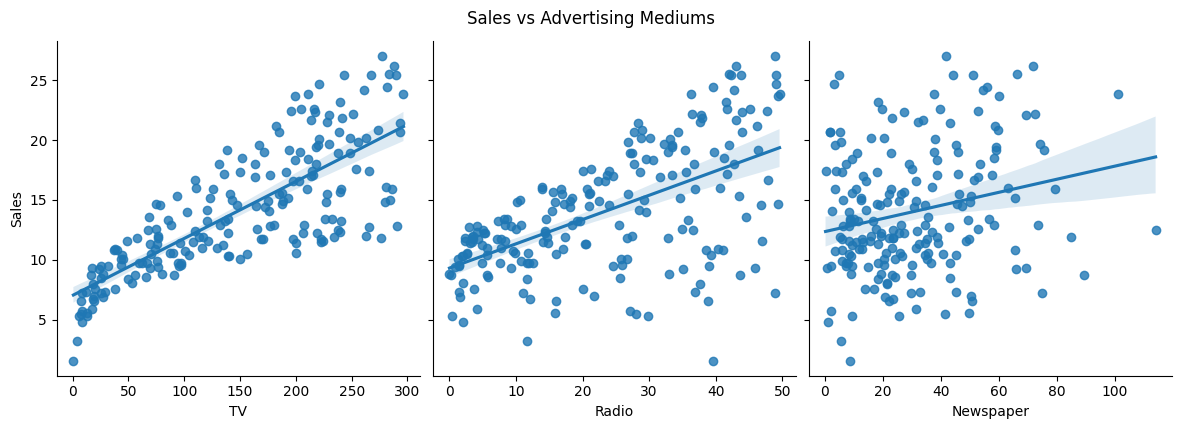

In [6]:
sns.pairplot(df, x_vars=["TV", "Radio", "Newspaper"], y_vars="Sales", height=4, aspect=1, kind="reg")
plt.suptitle("Sales vs Advertising Mediums", y=1.05)
plt.show()

Define Features and Target

In [7]:

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]


Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Training

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Predictions & Evaluation

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")

R2 Score: 0.8994
Mean Squared Error (MSE): 3.17
Mean Absolute Error (MAE): 1.46


The coefficient of which medium increases sales the most when advertising

In [13]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("\nAdvertising Coefficients:\n", coeff_df)


Advertising Coefficients:
            Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761
